# 🏙️ Munich Cost of Living — BI Dashboard
## Selenium Live Demo — MADSC301 Business Intelligence

In this demo we use Selenium to collect real cost of living 
data for Munich from Numbeo.com — then analyse and visualise 
it as a BI dashboard.

### Step 1 — Import all required libraries

In [4]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import matplotlib.pyplot as plt
import time

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### Step 2 — Launch Chrome Browser
Selenium will now open a real Chrome browser automatically.
No manual action needed — the script controls everything.

In [5]:
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")
options.add_argument("user-agent=Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.maximize_window()

print("✅ Browser launched successfully!")

✅ Browser launched successfully!


### Step 3 — Navigate to Munich Cost of Living Page
Selenium navigates to Numbeo.com — a website with no API 
and no export option. Only a real browser can read this data.

In [6]:
url = "https://www.numbeo.com/cost-of-living/in/Munich"
driver.get(url)
time.sleep(3)

print("✅ Navigated successfully!")
print("Page Title:", driver.title)
print("Current URL:", driver.current_url)

✅ Navigated successfully!
Page Title: Cost of Living in Munich. May 2026. Prices in Munich
Current URL: https://www.numbeo.com/cost-of-living/in/Munich


### Step 4 — Watch Selenium Extract Data Live
Selenium highlights each row gold as it reads — 
watch the browser carefully!

In [7]:
# Highlight rows so audience can see Selenium working
rows = driver.find_elements(By.CSS_SELECTOR, "table.data_wide_table tr")

for row in rows:
    try:
        driver.execute_script("arguments[0].style.backgroundColor = '#E8A020'", row)
        driver.execute_script("arguments[0].scrollIntoView();", row)
        time.sleep(0.3)
    except:
        pass

print(f"✅ Selenium read {len(rows)} rows from the page!")

✅ Selenium read 74 rows from the page!


### Step 5 — Structure Data into a Clean Table
Pandas organises the extracted data into a 
structured BI-ready table with correct categories.

In [8]:
# Extract data
rows = driver.find_elements(By.CSS_SELECTOR, "table.data_wide_table tr")

items = []
prices = []

for row in rows:
    cols = row.find_elements(By.TAG_NAME, "td")
    if len(cols) >= 2:
        item = cols[0].text.strip()
        price = cols[1].text.strip()
        if item and price:
            items.append(item)
            prices.append(price)

# Create DataFrame
df = pd.DataFrame({"Item": items, "Price (EUR)": prices})

# Clean prices
df["Price (EUR)"] = df["Price (EUR)"].str.replace("€", "").str.replace(",", "").str.strip()
df["Price (EUR)"] = pd.to_numeric(df["Price (EUR)"], errors="coerce")
df = df.dropna(subset=["Price (EUR)"])

# Assign correct categories
categories = (
    ["Restaurants"] * 8 +
    ["Markets"] * 19 +
    ["Transportation"] * 5 +
    ["Car Prices"] * 2 +
    ["Utilities"] * 3 +
    ["Sports & Leisure"] * 3 +
    ["Childcare"] * 2 +
    ["Clothing"] * 3 +
    ["Rent"] * 6 +
    ["Salaries"] * 4
)
df["Category"] = categories[:len(df)]

# Remove one-time purchases for accurate monthly analysis
df_monthly = df[~df["Category"].isin(["Car Prices"])]
df_monthly = df_monthly[~df_monthly["Item"].str.contains(
    "International Primary School|Price per Square Meter|Annual Mortgage", 
    case=False)]

print("✅ Data structured successfully!")
print(f"Total items: {len(df)} | Items for monthly analysis: {len(df_monthly)}")
print("\n", df_monthly.head(10).to_string(index=False))

✅ Data structured successfully!
Total items: 55 | Items for monthly analysis: 49

                                                                   Item  Price (EUR)    Category
                                     Meal at an Inexpensive Restaurant        18.00 Restaurants
Meal for Two at a Mid-Range Restaurant (Three Courses, Without Drinks)        80.00 Restaurants
               Combo Meal at McDonald's (or Equivalent Fast-Food Meal)        12.00 Restaurants
                                       Domestic Draft Beer (0.5 Liter)         4.90 Restaurants
                                     Imported Beer (0.33 Liter Bottle)         5.00 Restaurants
                                             Cappuccino (Regular Size)         3.91 Restaurants
                    Soft Drink (Coca-Cola or Pepsi, 0.33 Liter Bottle)         3.23 Restaurants
                                            Bottled Water (0.33 Liter)         2.80 Restaurants
                                               Milk (

### Step 6 — Chart 1: Average Monthly Cost by Category
Which category costs the most in Munich per month?

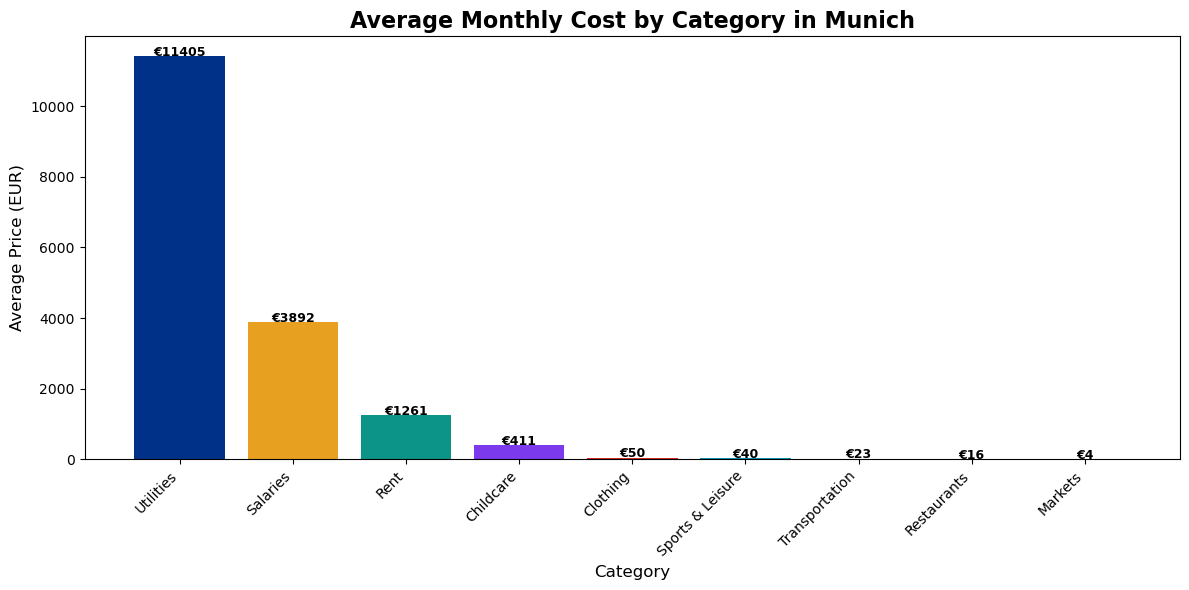

✅ Chart 1 generated!


In [9]:
avg_by_category = df_monthly.groupby("Category")["Price (EUR)"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ["#003189", "#E8A020", "#0D9488", "#7C3AED", 
          "#DC2626", "#0891B2", "#166534", "#92400E"]
bars = plt.bar(avg_by_category.index, avg_by_category.values, color=colors)

for bar, val in zip(bars, avg_by_category.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f"€{val:.0f}", ha="center", fontsize=9, fontweight="bold")

plt.title("Average Monthly Cost by Category in Munich", fontsize=16, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Average Price (EUR)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print("✅ Chart 1 generated!")

### Step 7 — Chart 2: Top 10 Most Expensive Monthly Items
The most expensive regular costs a resident faces in Munich.

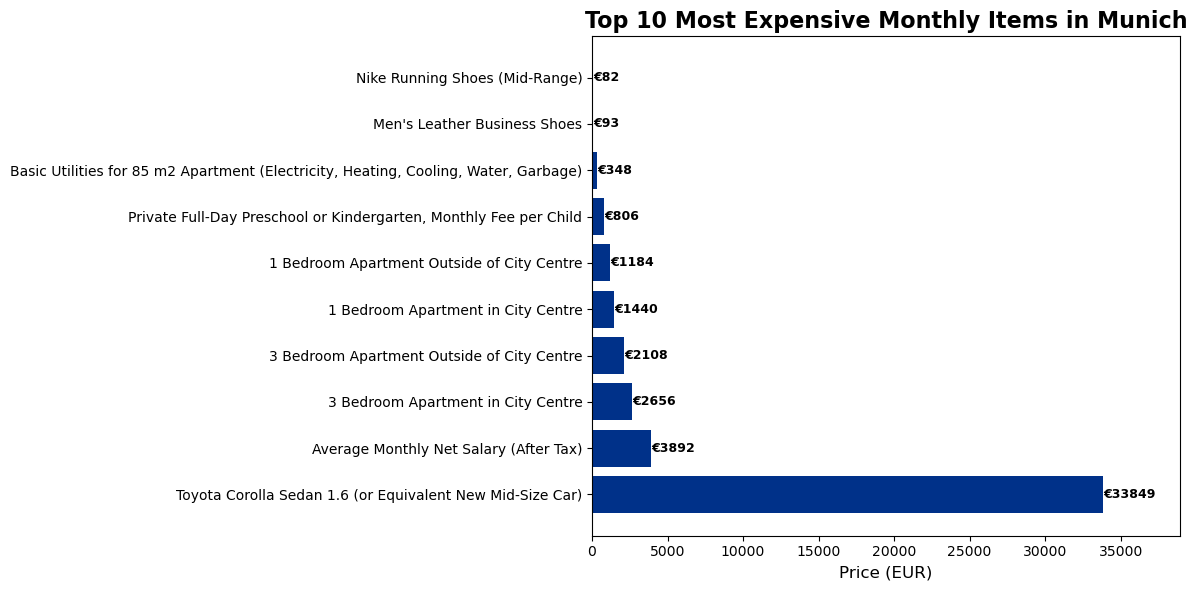

✅ Chart 2 generated!


In [10]:
top10 = df_monthly.nlargest(10, "Price (EUR)")

plt.figure(figsize=(12, 6))
bars = plt.barh(top10["Item"], top10["Price (EUR)"], color="#003189")

for bar, val in zip(bars, top10["Price (EUR)"]):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f"€{val:.0f}", va="center", fontsize=9, fontweight="bold")

plt.title("Top 10 Most Expensive Monthly Items in Munich", fontsize=16, fontweight="bold")
plt.xlabel("Price (EUR)", fontsize=12)
plt.xlim(0, top10["Price (EUR)"].max() * 1.15)
plt.tight_layout()
plt.show()
print("✅ Chart 2 generated!")

### Step 8 — Chart 3: Cost Breakdown by Category
How is the total cost of living distributed across categories in Munich?

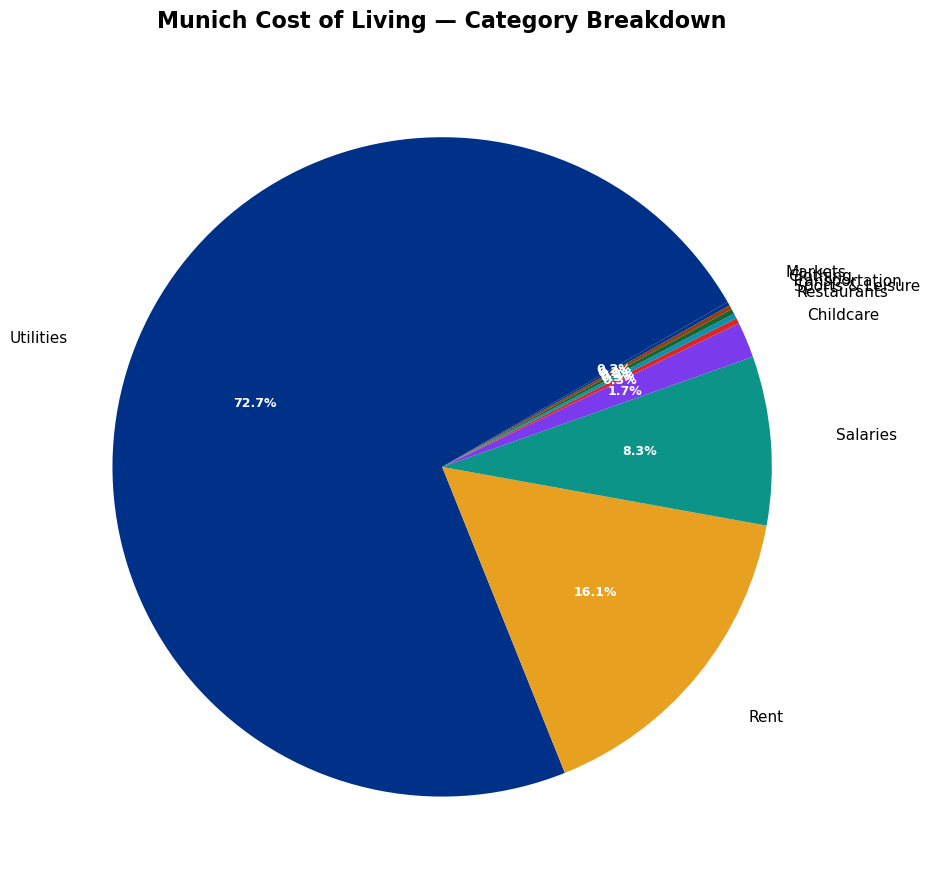

✅ Chart 3 generated!


In [13]:
total_by_category = df_monthly.groupby("Category")["Price (EUR)"].sum().sort_values(ascending=False)

colors = ["#003189", "#E8A020", "#0D9488", "#7C3AED",
          "#DC2626", "#0891B2", "#166534", "#92400E"]

fig, ax = plt.subplots(figsize=(14, 9))
wedges, texts, autotexts = ax.pie(
    total_by_category.values,
    labels=total_by_category.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=30,
    pctdistance=0.6,
    labeldistance=1.2,
    textprops={"fontsize": 11}
)

for autotext in autotexts:
    autotext.set_fontweight("bold")
    autotext.set_fontsize(9)
    autotext.set_color("white")

ax.set_title("Munich Cost of Living — Category Breakdown",
             fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()
print("✅ Chart 3 generated!")

### Step 9 — Key Performance Indicators
Key BI metrics extracted from the Munich cost of living data.

In [14]:
# Calculate KPIs
total_monthly = df_monthly["Price (EUR)"].sum()
avg_monthly = df_monthly["Price (EUR)"].mean()
most_expensive_item = df_monthly.loc[df_monthly["Price (EUR)"].idxmax(), "Item"]
most_expensive_price = df_monthly["Price (EUR)"].max()
cheapest_item = df_monthly.loc[df_monthly["Price (EUR)"].idxmin(), "Item"]
cheapest_price = df_monthly["Price (EUR)"].min()
most_expensive_category = df_monthly.groupby("Category")["Price (EUR)"].mean().idxmax()
avg_rent = df_monthly[df_monthly["Category"] == "Rent"]["Price (EUR)"].mean()
avg_salary = df_monthly[df_monthly["Category"] == "Salaries"]["Price (EUR)"].mean()
rent_salary_ratio = (avg_rent / avg_salary) * 100

print("=" * 55)
print("        MUNICH COST OF LIVING — KPI SUMMARY")
print("=" * 55)
print(f"  Total Monthly Cost (all items):    €{total_monthly:,.2f}")
print(f"  Average Price per Item:            €{avg_monthly:,.2f}")
print(f"  Most Expensive Category:           {most_expensive_category}")
print(f"  Average Monthly Rent:              €{avg_rent:,.2f}")
print(f"  Average Monthly Net Salary:        €{avg_salary:,.2f}")
print(f"  Rent as % of Salary:               {rent_salary_ratio:.1f}%")
print(f"  Most Expensive Item:               {most_expensive_item}")
print(f"  Most Expensive Price:              €{most_expensive_price:,.2f}")
print(f"  Cheapest Item:                     {cheapest_item}")
print(f"  Cheapest Price:                    €{cheapest_price:,.2f}")
print("=" * 55)

        MUNICH COST OF LIVING — KPI SUMMARY
  Total Monthly Cost (all items):    €47,039.80
  Average Price per Item:            €960.00
  Most Expensive Category:           Utilities
  Average Monthly Rent:              €1,260.60
  Average Monthly Net Salary:        €3,892.08
  Rent as % of Salary:               32.4%
  Most Expensive Item:               Toyota Corolla Sedan 1.6 (or Equivalent New Mid-Size Car)
  Most Expensive Price:              €33,849.23
  Cheapest Item:                     Bottled Water (1.5 Liter)
  Cheapest Price:                    €1.04


### Step 10 — Full BI Dashboard
A complete multi-chart dashboard combining all insights 
from the Munich cost of living data — ready for stakeholders.

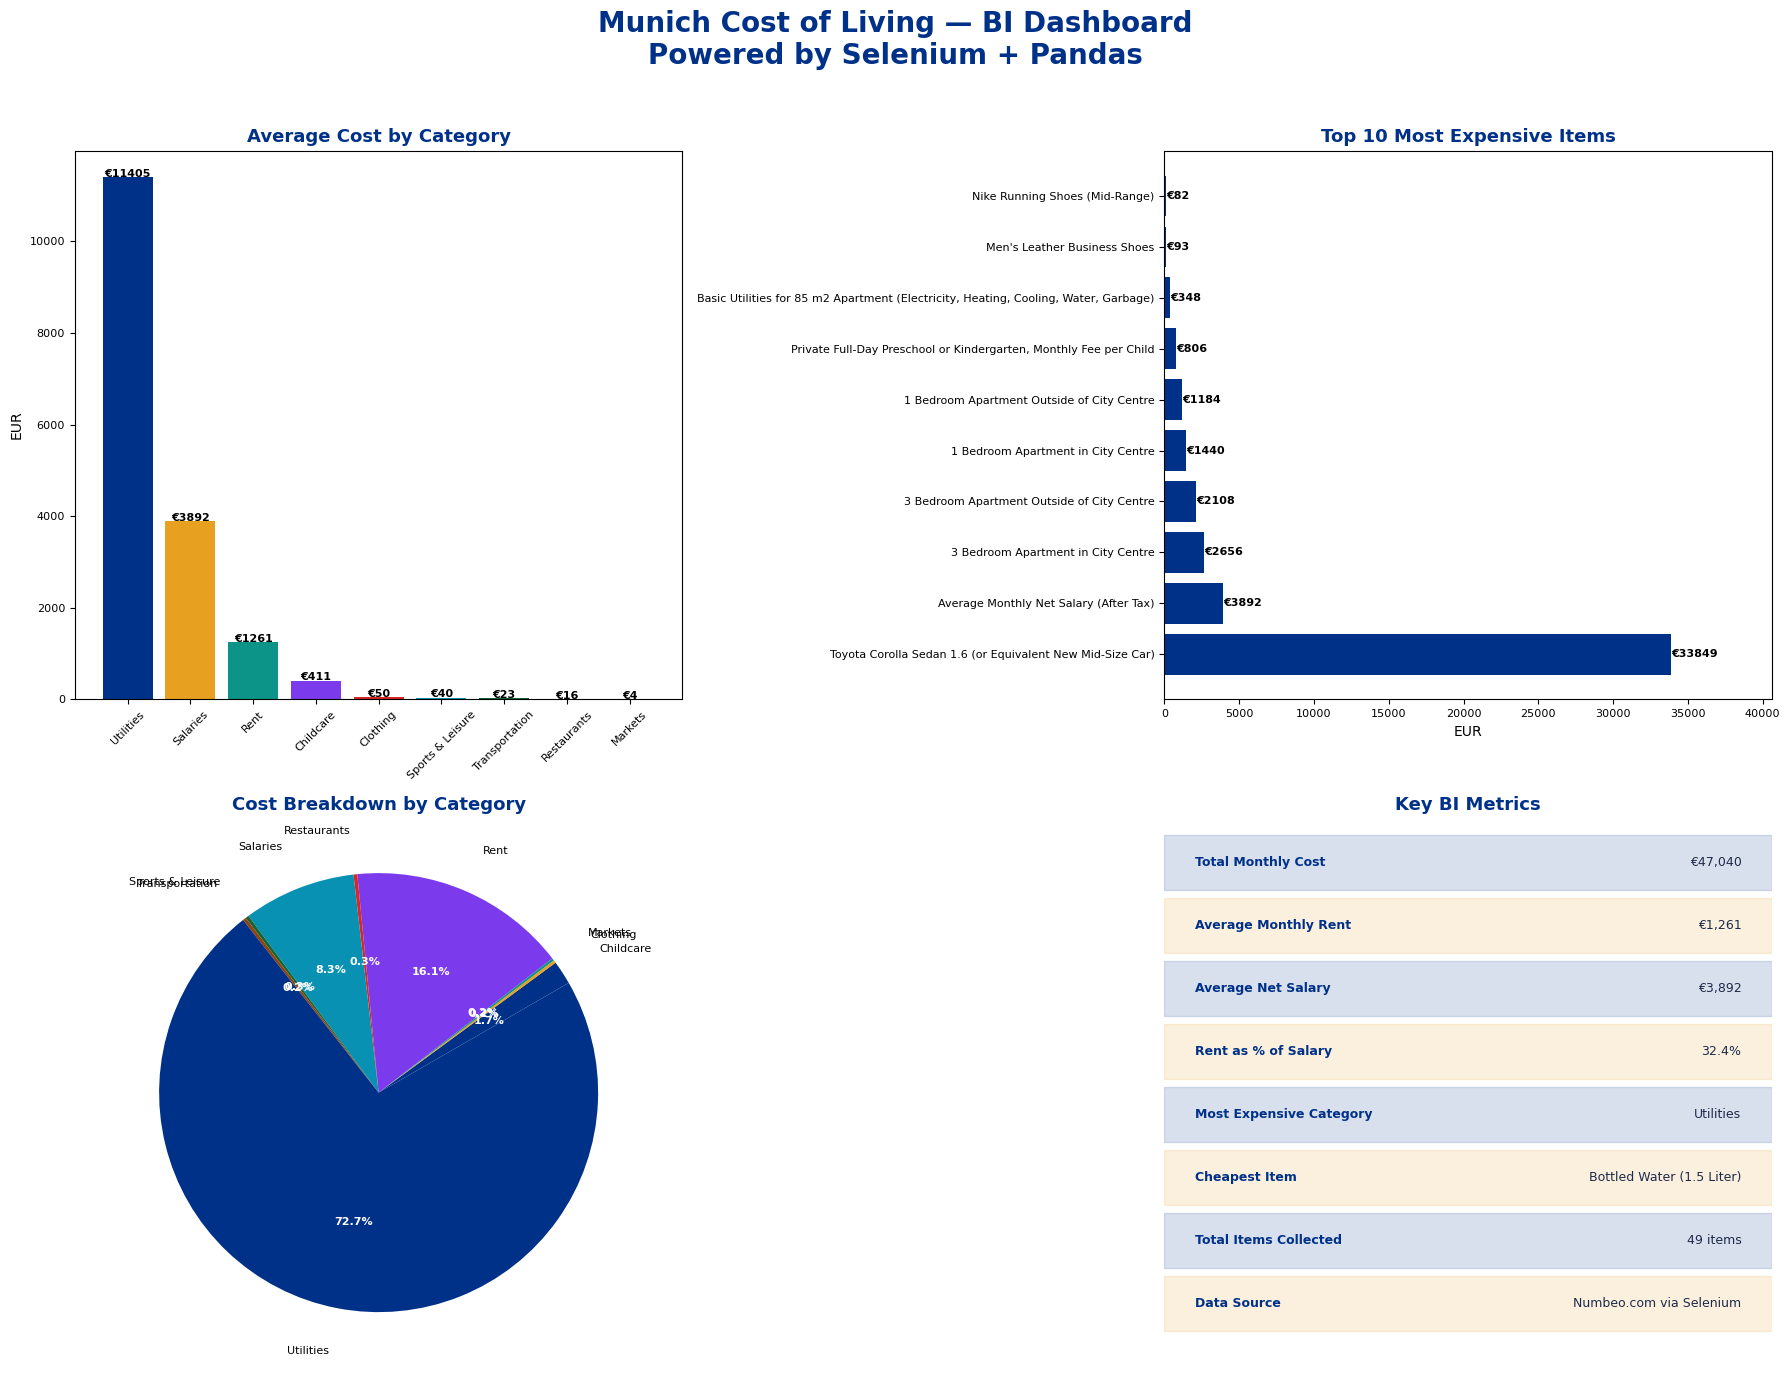

✅ Full BI Dashboard generated and saved as munich_bi_dashboard.png!


In [15]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Munich Cost of Living — BI Dashboard\nPowered by Selenium + Pandas", 
             fontsize=20, fontweight="bold", color="#003189", y=0.98)

colors = ["#003189", "#E8A020", "#0D9488", "#7C3AED",
          "#DC2626", "#0891B2", "#166534", "#92400E"]

# ── Chart 1: Average Cost by Category (top left)
ax1 = fig.add_subplot(2, 2, 1)
avg_by_cat = df_monthly.groupby("Category")["Price (EUR)"].mean().sort_values(ascending=False)
bars = ax1.bar(avg_by_cat.index, avg_by_cat.values, color=colors)
for bar, val in zip(bars, avg_by_cat.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f"€{val:.0f}", ha="center", fontsize=8, fontweight="bold")
ax1.set_title("Average Cost by Category", fontsize=13, fontweight="bold", color="#003189")
ax1.set_ylabel("EUR")
ax1.tick_params(axis="x", rotation=45)
ax1.tick_params(labelsize=8)

# ── Chart 2: Top 10 Most Expensive Items (top right)
ax2 = fig.add_subplot(2, 2, 2)
top10 = df_monthly.nlargest(10, "Price (EUR)")
bars2 = ax2.barh(top10["Item"], top10["Price (EUR)"], color="#003189")
for bar, val in zip(bars2, top10["Price (EUR)"]):
    ax2.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f"€{val:.0f}", va="center", fontsize=8, fontweight="bold")
ax2.set_title("Top 10 Most Expensive Items", fontsize=13, fontweight="bold", color="#003189")
ax2.set_xlabel("EUR")
ax2.tick_params(labelsize=8)
ax2.set_xlim(0, top10["Price (EUR)"].max() * 1.2)

# ── Chart 3: Pie Chart (bottom left)
ax3 = fig.add_subplot(2, 2, 3)
total_by_cat = df_monthly.groupby("Category")["Price (EUR)"].sum()
wedges, texts, autotexts = ax3.pie(
    total_by_cat.values,
    labels=total_by_cat.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=30,
    pctdistance=0.6,
    labeldistance=1.2,
    textprops={"fontsize": 8}
)
for autotext in autotexts:
    autotext.set_fontweight("bold")
    autotext.set_color("white")
    autotext.set_fontsize(8)
ax3.set_title("Cost Breakdown by Category", fontsize=13, fontweight="bold", color="#003189")

# ── Chart 4: KPI Summary (bottom right)
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis("off")

kpis = [
    ("Total Monthly Cost", f"€{df_monthly['Price (EUR)'].sum():,.0f}"),
    ("Average Monthly Rent", f"€{df_monthly[df_monthly['Category']=='Rent']['Price (EUR)'].mean():,.0f}"),
    ("Average Net Salary", f"€{df_monthly[df_monthly['Category']=='Salaries']['Price (EUR)'].mean():,.0f}"),
    ("Rent as % of Salary", f"{(df_monthly[df_monthly['Category']=='Rent']['Price (EUR)'].mean() / df_monthly[df_monthly['Category']=='Salaries']['Price (EUR)'].mean())*100:.1f}%"),
    ("Most Expensive Category", df_monthly.groupby('Category')['Price (EUR)'].mean().idxmax()),
    ("Cheapest Item", df_monthly.loc[df_monthly['Price (EUR)'].idxmin(), 'Item']),
    ("Total Items Collected", f"{len(df_monthly)} items"),
    ("Data Source", "Numbeo.com via Selenium"),
]

ax4.set_title("Key BI Metrics", fontsize=13, fontweight="bold", color="#003189")

for i, (label, value) in enumerate(kpis):
    y = 0.92 - i * 0.115
    ax4.add_patch(plt.Rectangle((0, y - 0.05), 1, 0.1,
                  color="#003189" if i % 2 == 0 else "#E8A020",
                  alpha=0.15, transform=ax4.transAxes))
    ax4.text(0.05, y, label, transform=ax4.transAxes,
             fontsize=9, fontweight="bold", color="#003189", va="center")
    ax4.text(0.95, y, value, transform=ax4.transAxes,
             fontsize=9, color="#1E2A4A", va="center", ha="right")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("munich_bi_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Full BI Dashboard generated and saved as munich_bi_dashboard.png!")

### Step 9 — The BI Pipeline Story
How this demo fits into a real production BI pipeline.

In [12]:
print("""
================================================
        REAL-WORLD BI PIPELINE STORY
================================================

WHAT WE JUST DID:
  Website (Numbeo.com)
      ↓
  Selenium — Collected 55 data points automatically
      ↓
  Pandas — Cleaned and structured the data
      ↓
  Matplotlib — Generated 3 BI charts

IN PRODUCTION THIS WOULD BE:
  Airflow schedules this script monthly
      ↓
  Data loads automatically into Snowflake
      ↓
  Power BI dashboard auto-refreshes
      ↓
  Business decisions made from live data

BUSINESS VALUE:
  No manual data collection
  Always up to date
  Scalable to any city worldwide
================================================
""")


        REAL-WORLD BI PIPELINE STORY

WHAT WE JUST DID:
  Website (Numbeo.com)
      ↓
  Selenium — Collected 55 data points automatically
      ↓
  Pandas — Cleaned and structured the data
      ↓
  Matplotlib — Generated 3 BI charts

IN PRODUCTION THIS WOULD BE:
  Airflow schedules this script monthly
      ↓
  Data loads automatically into Snowflake
      ↓
  Power BI dashboard auto-refreshes
      ↓
  Business decisions made from live data

BUSINESS VALUE:
  No manual data collection
  Always up to date
  Scalable to any city worldwide

